In [ ]:
# CORRELATION ANALYSIS NOTEBOOK
# This notebook performs correlation analysis between gene mutations and 
# light regime phenotypes using various methods including Sparse CCA and PCA

%load_ext autoreload
%autoreload 2

In [ ]:

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.multioutput import MultiOutputRegressor
from sparsecca import cca_pmd
from gprofiler import GProfiler

# Add project path to system path
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [ ]:

def split_genes_with_counts(data):
    """
    Split genes that are combined with '&' or ',' into separate rows.
    Each gene gets its own row with mutation count information.
    
    Parameters:
    -----------
    data : pd.DataFrame
        Input data with 'mutated_genes' column containing gene combinations
        
    Returns:
    --------
    pd.DataFrame
        Expanded dataframe with one gene per row
    """
    rows = []
    for _, row in data.iterrows():
        full_genes = str(row['mutated_genes']).strip()
        genes = [g.strip() for g in full_genes.replace('&', ',').split(',') if g.strip()]
        mutation_count = len(genes)
        for gene in genes:
            new_row = row.copy()
            new_row['mutated_genes'] = gene
            new_row['full_mutated_genes'] = full_genes
            new_row['mutation_count'] = mutation_count
            # Append mutation count to mutant_ID
            new_row['mutant_ID'] = f"{row['mutant_ID']}({mutation_count})"
            rows.append(new_row)
    
    data_expanded = pd.DataFrame(rows).reset_index(drop=True)
    if data_expanded.empty:
        print("Warning: no rows generated in split_genes_with_counts")
    return data_expanded


/Users/imanemokhtatif/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



### DATA LOADING AND PREPROCESSING

In [ ]:
# Load and preprocess the main dataset
data = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')

# Split combined genes into separate rows
data = split_genes_with_counts(data)

# Save the processed data
data.to_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18).csv', index=False)

print(f"Data shape after preprocessing: {data.shape}")
print(f"Unique genes: {data['mutated_genes'].nunique()}")
print(f"Unique mutants: {data['mutant_ID'].nunique()}")


### SPARSE CANONICAL CORRELATION ANALYSIS (CCA)

In [ ]:
# CCA Parameters
K = 7  # Number of canonical components
penalty_x = 0.3  # Penalty for X (genes)
penalty_y = 0.3  # Penalty for Y (phenotypes)
N_Y_PCS = None  # Number of Y PCs to use (None = use all)

# Load and prepare data for CCA
df = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18).csv')

# Filter data: remove WT, ensure valid genes and mutants, exclude 20h_ML regime
df = df[~(df['mutant_ID'] == 'WT')]
df = df[df['mutated_genes'].notna() & df['mutant_ID'].notna()]
df = df[~(df['light_regime'].isin(['20h_ML']))]

# Create presence matrix (genes x mutants)
df['presence'] = 1
X = df.pivot_table(index='mutated_genes', columns='mutant_ID', values='presence', fill_value=0)

# Create phenotype matrix (genes x light regimes) using mean y2_slope
Y = df.pivot_table(index='mutated_genes', columns='light_regime', values='y2_slope', aggfunc='mean')

# Find common genes and align matrices
common = X.index.intersection(Y.index)
X, Y = X.loc[common], Y.loc[common]

# Handle missing values and infinite values
Y = Y.fillna(Y.mean())
Y = Y.replace([np.inf, -np.inf], 0)

# Remove genes with no variance
X = X.loc[:, X.var() > 0]

# Standardize the data
X_scaled = StandardScaler().fit_transform(X)
Y_scaled = StandardScaler().fit_transform(Y)

# Remove rows with infinite values
mask = np.isfinite(X_scaled).all(axis=1) & np.isfinite(Y_scaled).all(axis=1)
X_scaled = X_scaled[mask]
Y_scaled = Y_scaled[mask]

print(f"Final data shapes - X: {X_scaled.shape}, Y: {Y_scaled.shape}")

## Perform Sparse CCA Analysis

Cleaned X: (589, 1083) Y PCs: (589, 7)

=== Canonical Component 1 ===
Correlation: 0.776
Correlated genes: ['LMJ.RY0402.073018(2)', 'LMJ.RY0402.234238(2)', 'LMJ.RY0402.120225(1)', 'LMJ.RY0402.127455(1)', 'LMJ.RY0402.230565(1)', 'LMJ.RY0402.232202(1)', 'LMJ.RY0402.177081(1)', 'LMJ.RY0402.165850(1)', 'LMJ.RY0402.256443(3)', 'LMJ.RY0402.243149(1)', 'LMJ.RY0402.237368(1)', 'LMJ.RY0402.105594(1)', 'LMJ.RY0402.077111(1)', 'LMJ.RY0402.172780(2)', 'LMJ.RY0402.173729(1)'] ...
Correlated Y PCs: ['PC1']

=== Canonical Component 2 ===
Correlation: 0.737
Correlated genes: ['LMJ.RY0402.092547(3)', 'LMJ.RY0402.145536(3)', 'LMJ.RY0402.234238(2)', 'LMJ.RY0402.184967(2)', 'LMJ.RY0402.193585(2)', 'LMJ.RY0402.115536(3)', 'LMJ.RY0402.220453(2)', 'LMJ.RY0402.118321(1)', 'LMJ.RY0402.178557(1)', 'LMJ.RY0402.172780(2)', 'LMJ.RY0402.113423(2)', 'LMJ.RY0402.227288(2)', 'LMJ.RY0402.046739(3)', 'LMJ.RY0402.073018(2)', 'LMJ.RY0402.140206(2)'] ...
Correlated Y PCs: ['PC2']

=== Canonical Component 3 ===
Correlation:

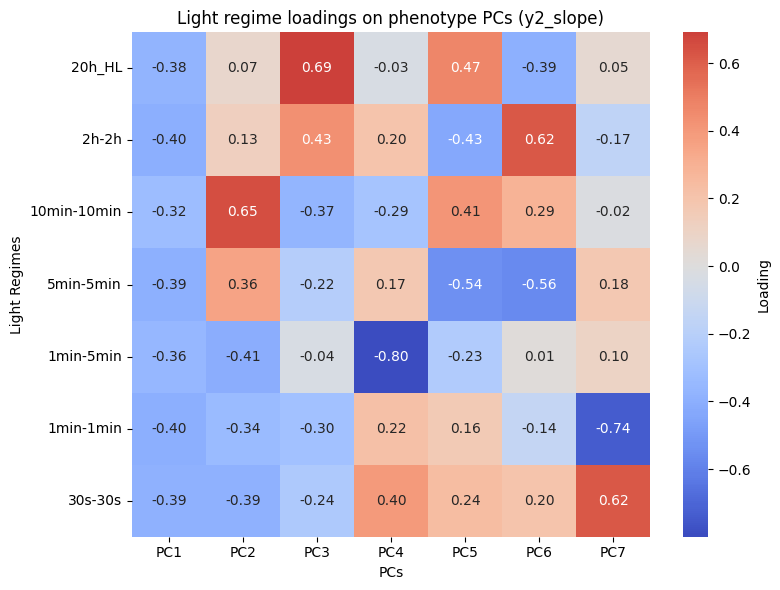

    PC  eigenvalue  variance_ratio  variance_pct  cum_pct
0  PC1       4.557           0.650        64.993   64.993
1  PC2       0.825           0.118        11.772   76.766
2  PC3       0.539           0.077         7.687   84.453
3  PC4       0.408           0.058         5.819   90.272
4  PC5       0.281           0.040         4.007   94.279
5  PC6       0.214           0.031         3.052   97.330
6  PC7       0.187           0.027         2.670  100.000


In [ ]:
K = 7
penalty_x = 0.3
penalty_y = 0.3
N_Y_PCS = None 

df = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18).csv')
df = df[~(df['mutant_ID']== 'WT')]
df = df[df['mutated_genes'].notna() & df['mutant_ID'].notna()]
df = df[~(df['light_regime'].isin(['20h_ML']))]

df['presence'] = 1
X = df.pivot_table(index='mutated_genes', columns= 'mutant_ID',
                   values='presence', fill_value=0)

Y = df.pivot_table(index='mutated_genes', columns='light_regime',
                   values='y2_slope', aggfunc='mean')

common = X.index.intersection(Y.index)
X, Y = X.loc[common], Y.loc[common]
Y = Y.fillna(Y.mean())
#Y = Y.clip(lower=-1e6, upper=1e6)
Y = Y.replace([np.inf, -np.inf], 0)
X = X.loc[:, X.var() > 0]

X_scaled = StandardScaler().fit_transform(X)
Y_scaled = StandardScaler().fit_transform(Y)

mask = np.isfinite(X_scaled).all(axis=1) & np.isfinite(Y_scaled).all(axis=1)
X_scaled = X_scaled[mask]
Y_scaled = Y_scaled[mask]

pca = PCA(n_components=N_Y_PCS, whiten=False)  
Y_pca_scores = pca.fit_transform(Y_scaled)     # shape: (n_samples, n_pcs)
pc_names = [f"PC{i+1}" for i in range(Y_pca_scores.shape[1])]

print("Cleaned X:", X_scaled.shape, "Y PCs:", Y_pca_scores.shape)

U, V, D = cca_pmd(
    X_scaled, Y_pca_scores,
    penaltyx=penalty_x,
    penaltyz=penalty_y,
    K=K,
    standardize=False
)
results = []
for k in range(K):
    X_ck = X_scaled @ U[:, k]
    Y_ck = Y_pca_scores @ V[:, k]
    corr_k = np.corrcoef(X_ck, Y_ck)[0, 1]
    # Sort important genes by absolute weight
    gene_weights = pd.Series(U[:, k], index=X.columns)
    important_genes = gene_weights[gene_weights.abs() > 1e-4] \
                        .abs() \
                        .sort_values(ascending=False) \
                        .index
    important_pcs = np.array(pc_names)[(abs(V[:, k]) > 1e-4)]
    results.append({
        "component": k+1,
        "correlation": corr_k,
        "genes": list(important_genes),
        "phenotypes": list(important_pcs)  # now PCs, not regimes
    })

for res in results:
    print(f"\n=== Canonical Component {res['component']} ===")
    print(f"Correlation: {res['correlation']:.3f}")
    print("Correlated genes:", res['genes'][:15], "..." if len(res['genes']) > 15 else "")
    print("Correlated Y PCs:", res['phenotypes'])

genes_used = X.columns
phenos_used = pc_names  # PCs used on the Y side

records = []
for k in range(K):
    X_ck = X_scaled @ U[:, k]
    Y_ck = Y_pca_scores @ V[:, k]
    corr_k = np.corrcoef(X_ck, Y_ck)[0, 1]
    for gene_idx, gene in enumerate(genes_used):
        if abs(U[gene_idx, k]) > 1e-4:
            for pheno_idx, pheno in enumerate(phenos_used):
                if abs(V[pheno_idx, k]) > 1e-4:
                    records.append({
                        "component": k+1,
                        "correlation": corr_k,
                        "gene": gene,
                        "gene_weight": abs(U[gene_idx, k]),
                        "light_regime": pheno,  # note: now a PC label
                        "pheno_weight": abs(V[pheno_idx, k])
                    })

results_df = pd.DataFrame(records)
# results_df.to_csv(
#     "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/cca_correlated_genes_lightregimes_with_weights.csv",
#     index=False
# )

#====================PLOTS
regime_order = ['20h_HL','20h_ML','2h-2h','10min-10min','5min-5min','1min-5min','1min-1min','30s-30s']
regime_order = [r for r in regime_order if r in Y.columns]  # garde seulement ceux présents

df_loadings = pd.DataFrame(
    pca.components_.T,
    index=Y.columns,
    columns=pc_names
).reindex(regime_order)

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    cbar_kws={"label": "Loading"}
)
plt.title("Light regime loadings on phenotype PCs (y2_slope)")
plt.ylabel("Light Regimes")
plt.xlabel("PCs")
plt.tight_layout()
plt.show()

# After fitting PCA -> `pca`
evr = pca.explained_variance_ratio_     
eig = pca.explained_variance_     

summary = pd.DataFrame({
    "PC": pc_names,
    "eigenvalue": eig,
    "variance_ratio": evr,
    "variance_pct": 100*evr,
    "cum_pct": 100*np.cumsum(evr)
})
print(summary.round(3))


In [ ]:
# Visualize PCA loadings and variance explained
regime_order = ['20h_HL','20h_ML','2h-2h','10min-10min','5min-5min','1min-5min','1min-1min','30s-30s']
regime_order = [r for r in regime_order if r in Y.columns]

# Create loadings heatmap
df_loadings = pd.DataFrame(
    pca.components_.T,
    index=Y.columns,
    columns=pc_names
).reindex(regime_order)

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    cbar_kws={"label": "Loading"}
)
plt.title("Light regime loadings on phenotype PCs (y2_slope)")
plt.ylabel("Light Regimes")
plt.xlabel("PCs")
plt.tight_layout()
plt.show()

# PCA variance summary
evr = pca.explained_variance_ratio_     
eig = pca.explained_variance_     

summary = pd.DataFrame({
    "PC": pc_names,
    "eigenvalue": eig,
    "variance_ratio": evr,
    "variance_pct": 100*evr,
    "cum_pct": 100*np.cumsum(evr)
})
print("PCA Variance Summary:")
print(summary.round(3))



### GENE ANALYSIS AND VISUALIZATION


In [ ]:
# Define genes of interest for analysis
genes_of_interest = [
    'Cre12.g531900', 'Cre16.g661200', 'Cre07.g314800',
    'Cre13.g588150', 'Cre06.g278110', 'Cre05.g235800',
    'Cre02.g105350', 'Cre13.g581900', 'Cre07.g323450',
    'Cre15.g635800'
]

# Check which genes are present in the CCA results
flagged_hits = results_df[results_df['gene'].isin(genes_of_interest)].copy()
found_genes = set(flagged_hits['gene'])
missing_genes = set(genes_of_interest) - found_genes

print("=== Flagged Genes Found in CCA ===")
print(flagged_hits[['component','light_regime','gene','gene_weight','pheno_weight']].sort_values(['gene','component']))
print("\n=== Flagged Genes Missing from CCA ===")
print(missing_genes if missing_genes else "None — all flagged genes found!")

# Save flagged genes results
flagged_hits.to_csv(
    "/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/flagged_genes_in_cca_with_weights.csv",
    index=False
)

[]


In [ ]:
# Visualize top gene contributions for a specific component
def plot_component_genes(component_idx, n_genes=20):
    """Plot top gene contributions for a given component"""
    weights = np.abs(U[:, component_idx])
    top_idx = np.argsort(weights)[::-1][:n_genes]
    
    plt.figure(figsize=(10, 5))
    plt.bar(np.array(X.columns)[top_idx], weights[top_idx])
    plt.title(f"Top {n_genes} Gene contributions to Component {component_idx+1}")
    plt.ylabel("|Weight|")
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()
    plt.show()

# Example: plot top genes for component 3 (index 2)
plot_component_genes(2, n_genes=20)

=== Flagged Genes Found in CCA ===
     component light_regime           gene  gene_weight  pheno_weight
142          2        2h-2h  Cre02.g105350     0.000201           1.0
373          4    1min-5min  Cre05.g235800     0.004599           1.0
169          2        2h-2h  Cre07.g323450     0.042810           1.0
393          4    1min-5min  Cre07.g323450     0.032225           1.0
85           1    1min-1min  Cre12.g531900     0.395885           1.0
206          2        2h-2h  Cre12.g531900     0.107488           1.0
439          4    1min-5min  Cre12.g531900     0.617097           1.0
449          4    1min-5min  Cre13.g581900     0.151351           1.0
451          4    1min-5min  Cre13.g588150     0.208654           1.0
221          2        2h-2h  Cre15.g635800     0.020781           1.0
457          4    1min-5min  Cre15.g635800     0.059126           1.0

=== Flagged Genes Missing from CCA ===
{'Cre07.g314800', 'Cre16.g661200', 'Cre06.g278110'}


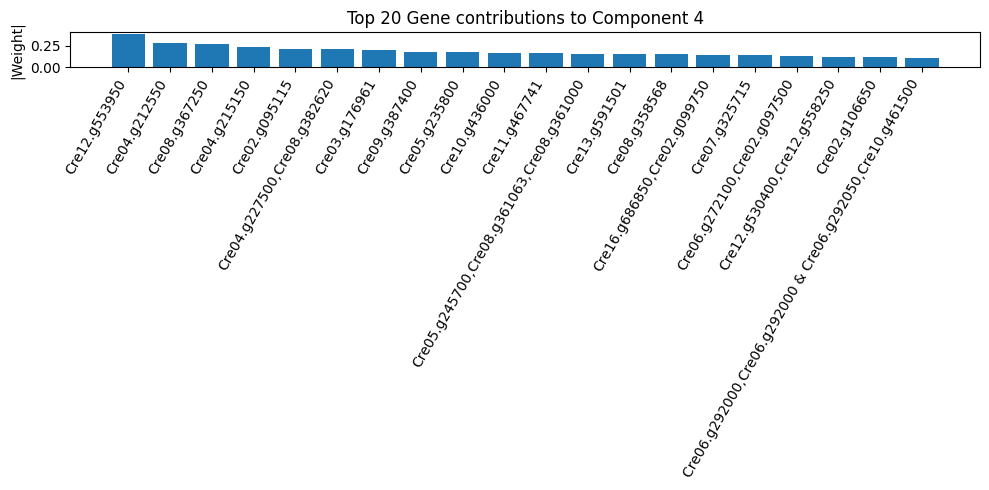

In [ ]:
k = 3  # component index (0 = Component 1)
N = 20 # how many top genes to show

weights = np.abs(U[:,k])
top_idx = np.argsort(weights)[::-1][:N]

plt.figure(figsize=(10,5))
plt.bar(np.array(X.columns)[top_idx], weights[top_idx])
plt.title(f"Top {N} Gene contributions to Component {k+1}")
plt.ylabel("|Weight|")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


### Other cca from  R code

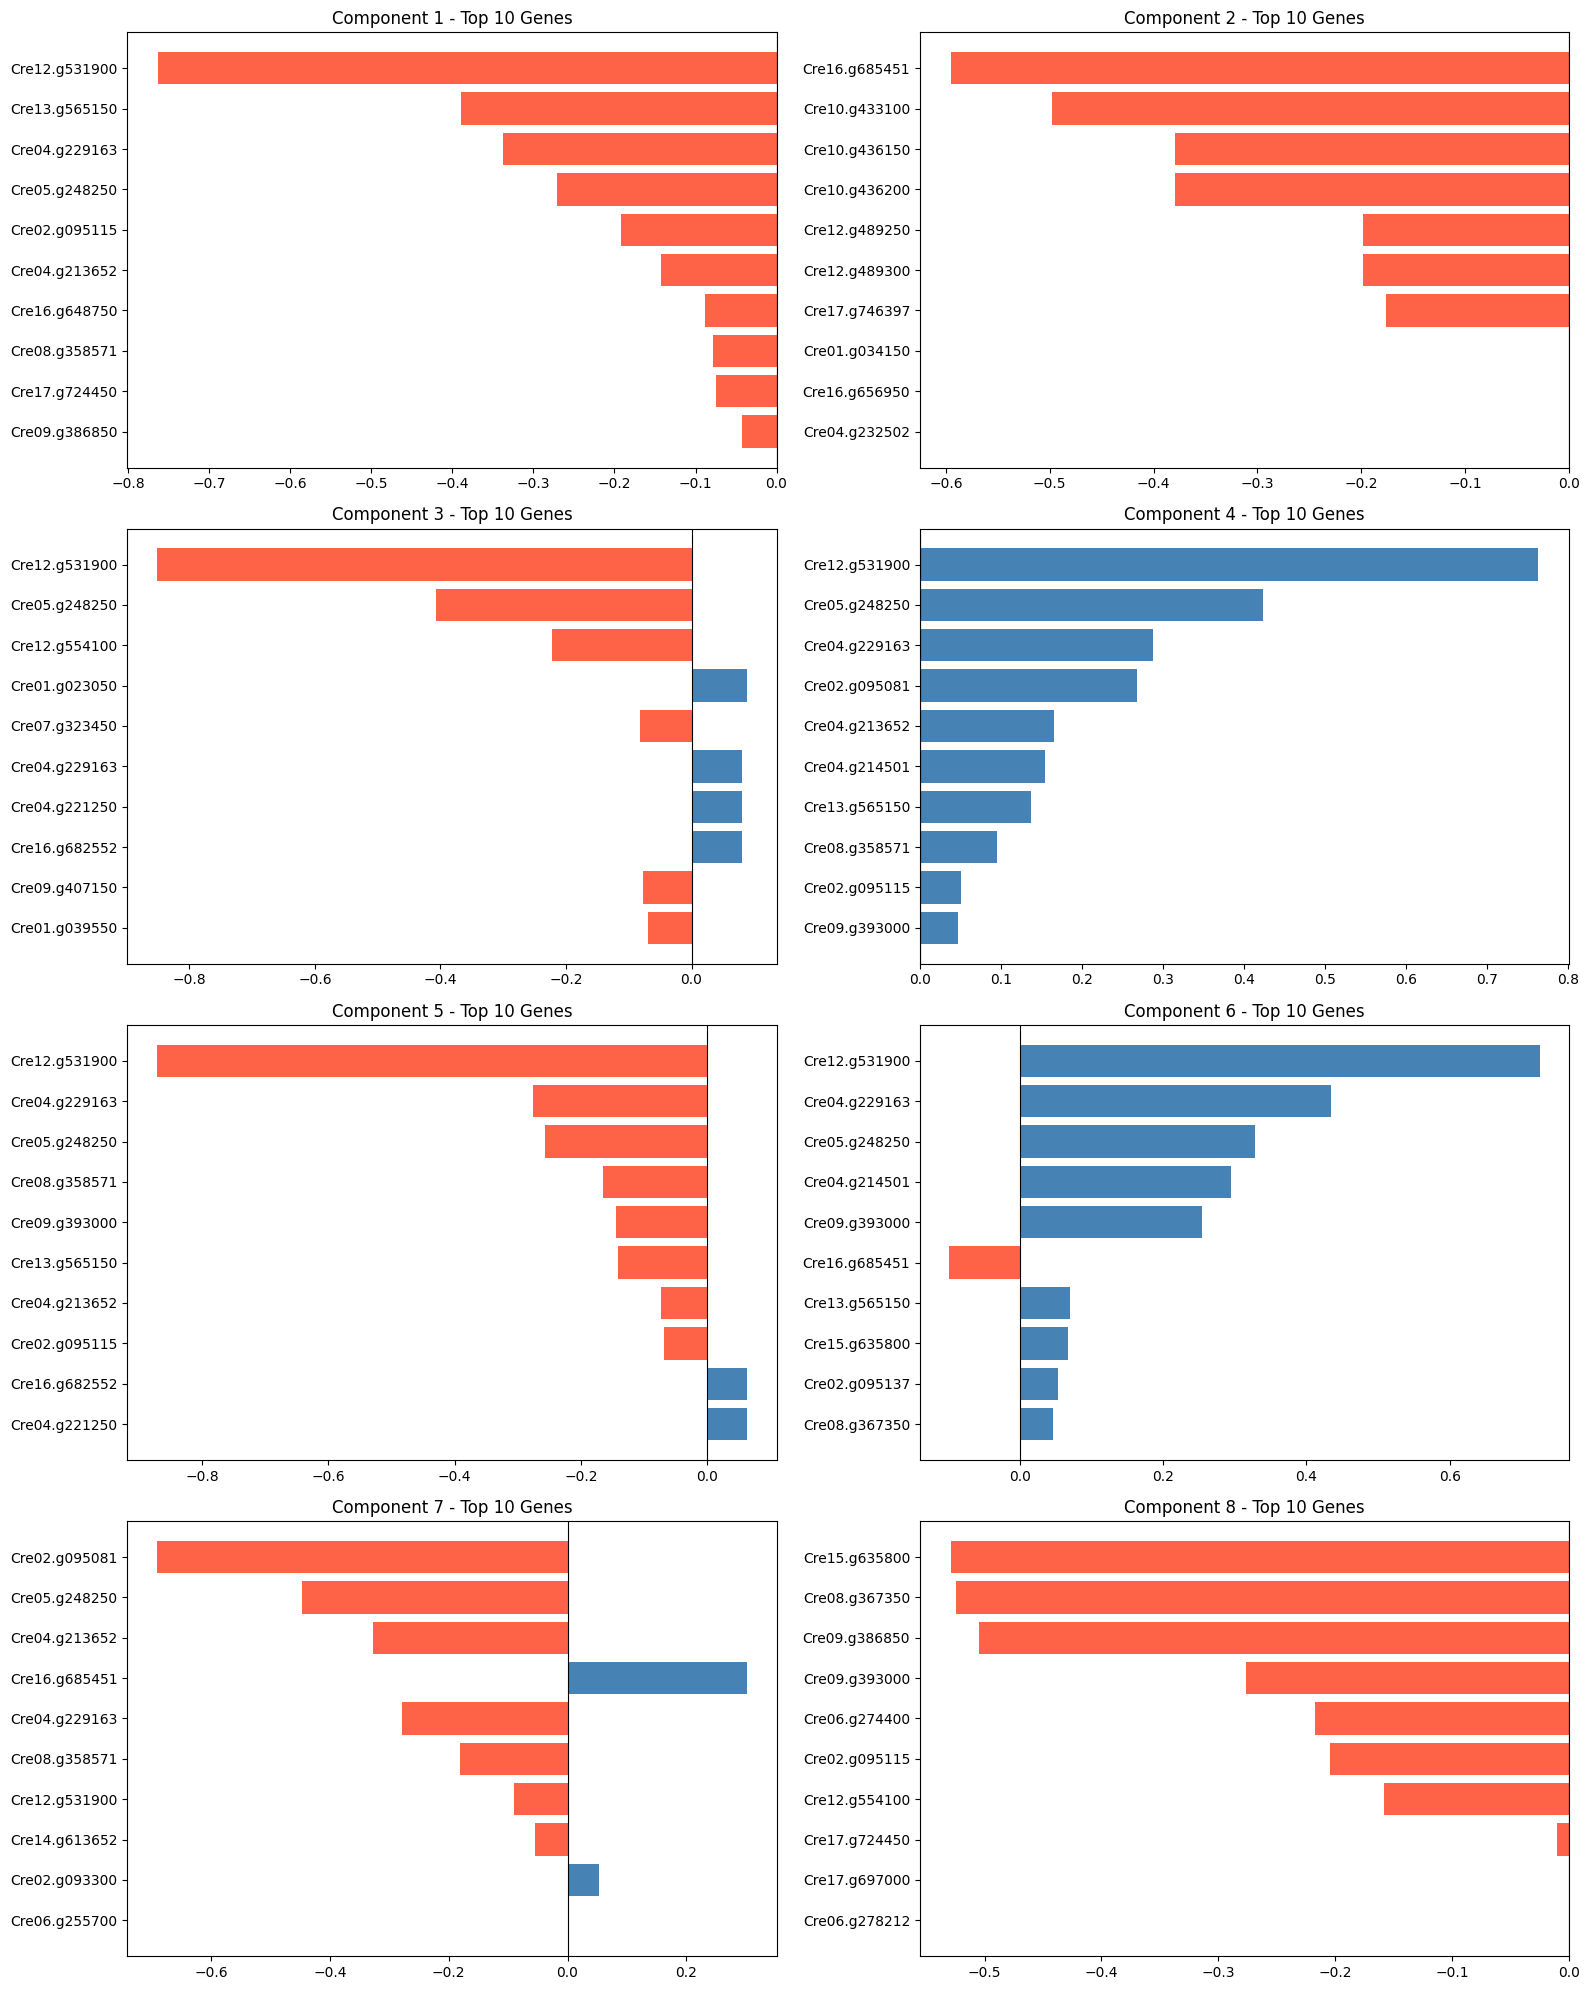

In [ ]:
# Compare gene weights across different CCA methods
def compare_cca_methods():
    """Compare gene weights across different CCA implementations"""
    
    # Define genes of interest
    genes_of_interest = [
        'Cre16.g661200', 'Cre07.g314800', 'Cre13.g588150',
        'Cre06.g278110', 'Cre05.g235800', 'Cre02.g105350',
        'Cre13.g581900', 'Cre07.g323450', 'Cre15.g635800'
    ]
    
    # File paths for different CCA methods
    files = {
        'Standard CCA': "/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/sCCA/STANDARD_sCCA_full_results.csv",
        'ECCA': "/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/sCCA/ECCA_results.csv",
        'CCA-RRR': "/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/sCCA/CCA_rr_component_results.csv",
        'cca_pmd': "/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/sCCA/python_scca_pmd_results.csv"
    }
    
    all_dfs = []
    
    for method, path in files.items():
        try:
            df = pd.read_csv(path)
            df = df[
                (df['component'] == 1) & 
                (df['type'] == 'gene') & 
                (df['name'].isin(genes_of_interest))
            ]
            df['method'] = method
            all_dfs.append(df)
        except FileNotFoundError:
            print(f"File not found: {path}")
    
    if all_dfs:
        combined_df = pd.concat(all_dfs)
        
        plt.figure(figsize=(10, 6))
        for gene in genes_of_interest:
            subset = combined_df[combined_df['name'] == gene]
            if not subset.empty:
                plt.plot(subset['method'], subset['weight'], marker='o', label=gene)
        
        plt.axhline(0, linestyle='--', color='gray')
        plt.ylabel("Gene weight (Component 1)")
        plt.title("Gene weights across CCA methods (Component 1)")
        plt.legend(title="Gene", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("No CCA comparison files found")

# Run comparison (uncomment if files exist)
# compare_cca_methods()


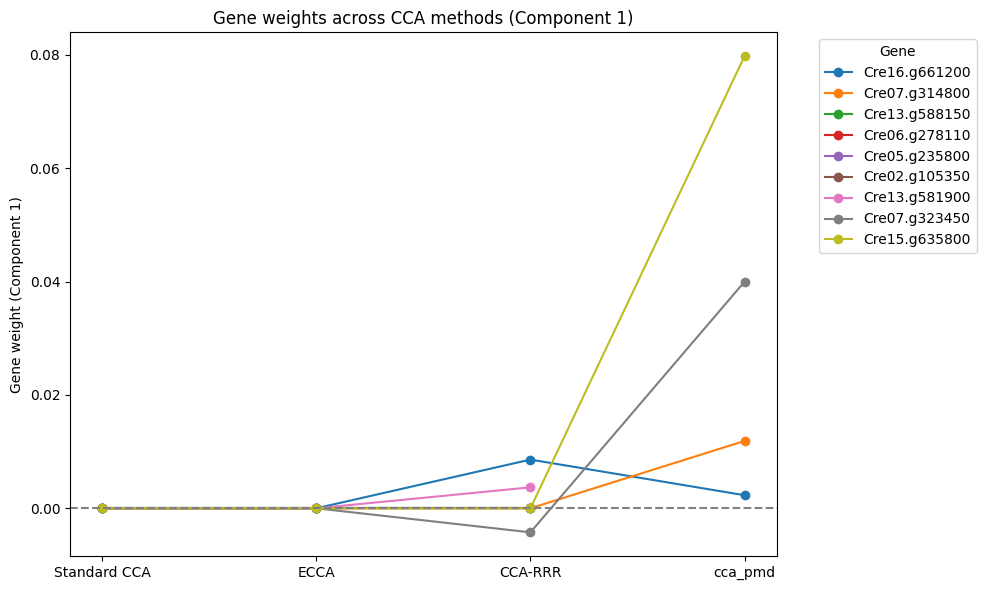

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === Parameters ===
genes_of_interest = [
'Cre16.g661200',
'Cre07.g314800',
'Cre13.g588150',
'Cre06.g278110',
'Cre05.g235800',
'Cre02.g105350',
'Cre13.g581900',
'Cre07.g323450','Cre15.g635800']

files = {
    'Standard CCA': "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/STANDARD_sCCA_full_results.csv",
    'ECCA': "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/ECCA_results.csv",
    'CCA-RRR': "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/CCA_rr_component_results.csv",
    'cca_pmd': "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/python_scca_pmd_results.csv"
}

all_dfs = []

for method, path in files.items():
    df = pd.read_csv(path)
    df = df[
        (df['component'] == 1) & 
        (df['type'] == 'gene') & 
        (df['name'].isin(genes_of_interest))
    ]
    df['method'] = method
    all_dfs.append(df)

combined_df = pd.concat(all_dfs)

plt.figure(figsize=(10, 6))
for gene in genes_of_interest:
    subset = combined_df[combined_df['name'] == gene]
    plt.plot(subset['method'], subset['weight'], marker='o', label=gene)

plt.axhline(0, linestyle='--', color='gray')
plt.ylabel("Gene weight (Component 1)")
plt.title("Gene weights across CCA methods (Component 1)")
plt.legend(title="Gene", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



### PCA-BASED ANALYSIS WITH LASSO REGRESSION



(1083, 8) (1083, 589)
               abs_coef       PC6
mutated_genes                    
Cre04.g229163  0.001046 -0.001046
Cre11.g467742  0.000786  0.000786
Cre10.g438750  0.000534  0.000534
Cre09.g393000  0.000514 -0.000514
Cre02.g093300  0.000327  0.000327
Cre02.g076200  0.000242 -0.000242
Cre12.g554100  0.000172  0.000172
Cre02.g095111  0.000151  0.000151
Cre01.g000650  0.000013  0.000013
Cre13.g588950  0.000013 -0.000013
Cre12.g488850  0.000000 -0.000000
Cre11.g482101  0.000000 -0.000000
Cre11.g483400  0.000000  0.000000
Cre12.g486900  0.000000 -0.000000
Cre12.g488400  0.000000 -0.000000
Cre10.g463550  0.000000  0.000000
Cre12.g489250  0.000000  0.000000
Cre11.g478456  0.000000 -0.000000
Cre12.g489300  0.000000  0.000000
Cre12.g489500  0.000000 -0.000000
Cre12.g492500  0.000000  0.000000
Cre12.g493050  0.000000  0.000000
Cre12.g495175  0.000000  0.000000
Cre11.g479300  0.000000 -0.000000
Cre11.g476050  0.000000  0.000000


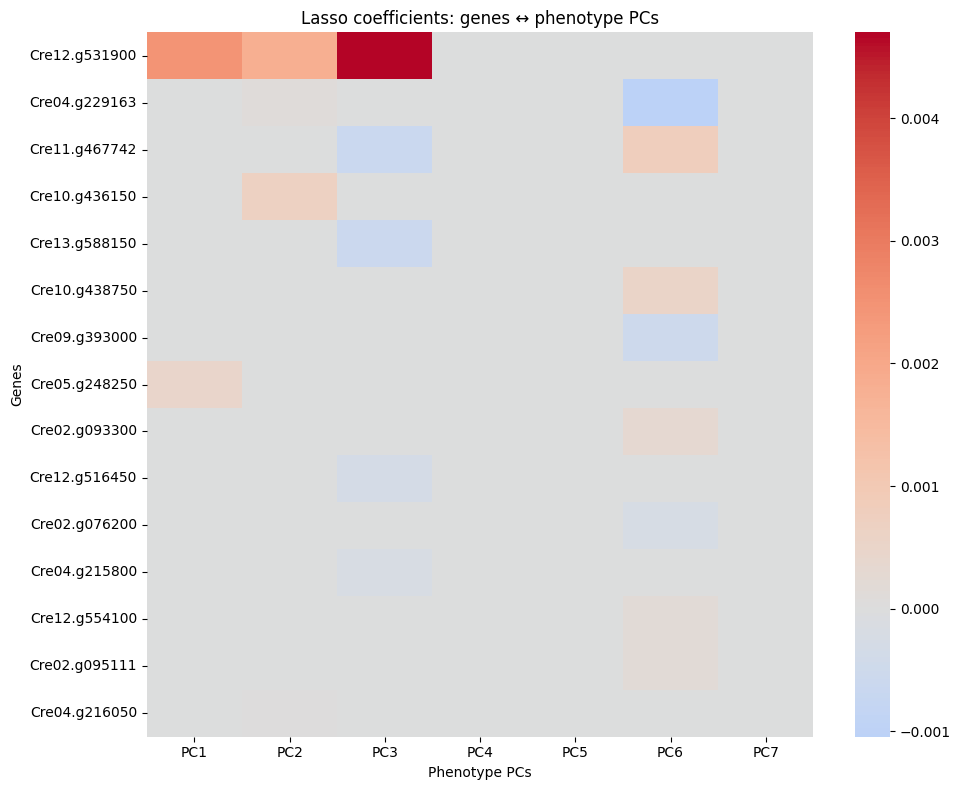

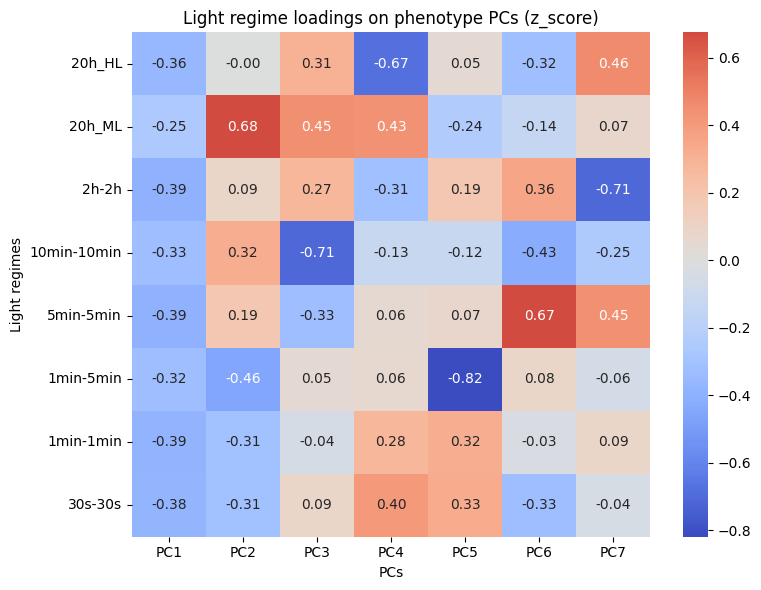

    PC   mean_r2    std_r2     alpha
0  PC1 -0.054457  0.100763  0.004791
1  PC2 -0.007874  0.007562  0.003498
2  PC3 -0.001886  0.003622  0.002547
3  PC4 -0.016623  0.029700  0.004524
4  PC5 -0.016228  0.021231  0.004067
5  PC6 -0.007895  0.007443  0.002586
6  PC7 -0.014113  0.010277  0.004553
Mean R^2 across all PCs: -0.01701096858976884


In [ ]:
# Load and prepare data for PCA-Lasso analysis
df = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18).csv')

# Filter valid data
df = df[df['mutant_ID'].notna() & df['mutated_genes'].notna()]

# Create presence matrix (mutants x genes)
df['presence'] = 1
X = df.pivot_table(index='mutant_ID', columns='mutated_genes', values='presence', fill_value=0)

# Create phenotype matrix (mutants x light regimes)
Y = df.pivot_table(index='mutant_ID', columns='light_regime', values='y2_slope', aggfunc='mean')
Y = Y.replace([np.inf, -np.inf], 0)

print(f"Data shapes - X: {X.shape}, Y: {Y.shape}")

# Align matrices and clean data
common = X.index.intersection(Y.index)
X = X.loc[common]
Y = Y.loc[common]
Y = Y.fillna(Y.mean())
X = X.loc[:, X.var() > 0]

# Standardize data
yscaler = StandardScaler()
Y_scaled = yscaler.fit_transform(Y)

xscaler = StandardScaler(with_mean=False)
X_scaled = xscaler.fit_transform(X)

# Apply PCA to phenotypes
K = 7
pca = PCA(n_components=K)       
Y_scores = pca.fit_transform(Y_scaled)
Y_white = Y_scores / pca.singular_values_

# --- 2) Lasso: predict each PC of Y via X to get parcimonious U 
xscaler = StandardScaler(with_mean=False)
X_scaled = xscaler.fit_transform(X)

alphas = None  # laisse LassoCV choisir
lasso_cv_kwargs = dict(cv=5, n_alphas=100, max_iter=5000, alphas=alphas)

U_coefs = []
for k in range(K):
    yk = Y_white[:, k]
    model = LassoCV(**lasso_cv_kwargs).fit(X_scaled, yk)
    U_coefs.append(model.coef_)

# Matrice U: gènes x PCs
U = pd.DataFrame(np.column_stack(U_coefs),
                 index=X.columns,
                 columns=[f"PC{k+1}" for k in range(K)])

# a) Scree plot: pca.explained_variance_ratio_ 
explained = pd.Series(pca.explained_variance_ratio_,
                      index=[f"PC{i+1}" for i in range(Y_white.shape[1])])

# b) Top genes par PC 
def top_genes_for_pc(U, pc, n=15):
    return U[pc].abs().sort_values(ascending=False).head(n).to_frame("abs_coef").join(U[[pc]])

top_PC1 = top_genes_for_pc(U, "PC6", n=25)
print(top_PC1)

# - explained : variance expliquée par PC (pour scree plot)
# - U : coefficients Lasso (gènes x PCs) = association gènes↔directions phénotypiques
# - top_PC1 (etc.) : gènes majeurs pour chaque PC


# Sort genes by their strongest coefficient magnitude
gene_order = U.abs().max(axis=1).sort_values(ascending=False).index[:15]  # top 50 genes
plt.figure(figsize=(10, 8))
sns.heatmap(U.loc[gene_order], cmap='coolwarm', center=0, annot=False)
plt.title("Lasso coefficients: genes ↔ phenotype PCs")
plt.xlabel("Phenotype PCs")
plt.ylabel("Genes")
plt.tight_layout()
plt.show()

regime_order = ['20h_HL','20h_ML','2h-2h','10min-10min','5min-5min','1min-5min','1min-1min','30s-30s']

loadings = pd.DataFrame(pca.components_.T,
                        index=Y.columns,  # original light regimes
                        columns=[f"PC{i+1}" for i in range(pca.n_components_)]).reindex(regime_order)

plt.figure(figsize=(8, 6))
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt=".2f") #.iloc[:, :2]
plt.title("Light regime loadings on phenotype PCs (z_score)")
plt.xlabel("PCs")
plt.ylabel("Light regimes")
plt.tight_layout()
plt.show()

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LassoCV
import numpy as np
import pandas as pd

alphas = None
lasso_cv_kwargs = dict(cv=5, n_alphas=100, max_iter=5000, alphas=alphas)

results = []
for k, pc in enumerate(Y_white.T):   # each column = PC scores
    model = LassoCV(**lasso_cv_kwargs).fit(X_scaled, pc)
    
    # Cross-validated R^2
    scores = cross_val_score(model, X_scaled, pc,
                             cv=5, scoring='r2')
    results.append(dict(PC=f"PC{k+1}",
                        mean_r2=np.mean(scores),
                        std_r2=np.std(scores),
                        alpha=model.alpha_))

r2_df = pd.DataFrame(results)
print(r2_df)
from sklearn.multioutput import MultiOutputRegressor

multi = MultiOutputRegressor(LassoCV(**lasso_cv_kwargs))
scores = cross_val_score(multi, X_scaled, Y_white,
                         cv=5, scoring='r2')
print("Mean R^2 across all PCs:", scores.mean())

In [ ]:
# Apply Lasso regression to predict each PC from gene presence
lasso_cv_kwargs = dict(cv=5, n_alphas=100, max_iter=5000, alphas=None)

U_coefs = []
for k in range(K):
    yk = Y_white[:, k]
    model = LassoCV(**lasso_cv_kwargs).fit(X_scaled, yk)
    U_coefs.append(model.coef_)

# Create coefficient matrix (genes x PCs)
U = pd.DataFrame(np.column_stack(U_coefs),
                 index=X.columns,
                 columns=[f"PC{k+1}" for k in range(K)])

# Function to get top genes for a PC
def top_genes_for_pc(U, pc, n=15):
    """Get top n genes for a given PC based on absolute coefficient values"""
    return U[pc].abs().sort_values(ascending=False).head(n).to_frame("abs_coef").join(U[[pc]])

# Example: top genes for PC6
top_PC6 = top_genes_for_pc(U, "PC6", n=25)
print("Top genes for PC6:")
print(top_PC6)


In [ ]:
# Visualize Lasso coefficients and PCA loadings
# Sort genes by their strongest coefficient magnitude
gene_order = U.abs().max(axis=1).sort_values(ascending=False).index[:15]

plt.figure(figsize=(10, 8))
sns.heatmap(U.loc[gene_order], cmap='coolwarm', center=0, annot=False)
plt.title("Lasso coefficients: genes ↔ phenotype PCs")
plt.xlabel("Phenotype PCs")
plt.ylabel("Genes")
plt.tight_layout()
plt.show()

# PCA loadings heatmap
regime_order = ['20h_HL','20h_ML','2h-2h','10min-10min','5min-5min','1min-5min','1min-1min','30s-30s']
loadings = pd.DataFrame(pca.components_.T,
                        index=Y.columns,
                        columns=[f"PC{i+1}" for i in range(pca.n_components_)]).reindex(regime_order)

plt.figure(figsize=(8, 6))
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Light regime loadings on phenotype PCs")
plt.xlabel("PCs")
plt.ylabel("Light regimes")
plt.tight_layout()
plt.show()


In [ ]:
# Cross-validation analysis for Lasso models
results = []
for k, pc in enumerate(Y_white.T):
    model = LassoCV(**lasso_cv_kwargs).fit(X_scaled, pc)
    
    # Cross-validated R^2
    scores = cross_val_score(model, X_scaled, pc, cv=5, scoring='r2')
    results.append(dict(PC=f"PC{k+1}",
                        mean_r2=np.mean(scores),
                        std_r2=np.std(scores),
                        alpha=model.alpha_))

r2_df = pd.DataFrame(results)
print("Cross-validation R² results:")
print(r2_df)

# Multi-output regression
multi = MultiOutputRegressor(LassoCV(**lasso_cv_kwargs))
scores = cross_val_score(multi, X_scaled, Y_white, cv=5, scoring='r2')
print(f"\nMean R² across all PCs: {scores.mean():.4f}")


Top 3 mutants on PC1:
 mutated_genes
Cre06.g251050    5.149925
Cre12.g489300    4.535901
Cre13.g589300    4.353730
Name: PC1, dtype: float64
Bottom 3 mutants on PC1:
 mutated_genes
Cre04.g229163   -13.110407
Cre13.g565150   -12.007401
Cre05.g248250   -11.304962
Name: PC1, dtype: float64
Top 3 mutants on PC2:
 mutated_genes
Cre10.g436150    5.603049
Cre12.g489300    4.508315
Cre04.g229163    4.479169
Name: PC2, dtype: float64
Bottom 3 mutants on PC2:
 mutated_genes
Cre02.g095076   -2.588297
Cre12.g527100   -1.984249
Cre12.g538850   -1.889449
Name: PC2, dtype: float64
Top 3 mutants on PC3:
 mutated_genes
Cre11.g467742    3.589277
Cre13.g581850    2.647418
Cre01.g016556    2.388305
Name: PC3, dtype: float64
Bottom 3 mutants on PC3:
 mutated_genes
Cre12.g531900   -4.286387
Cre10.g436150   -2.385417
Cre04.g227500   -2.281859
Name: PC3, dtype: float64
Top 3 mutants on PC4:
 mutated_genes
Cre17.g717200    1.986408
Cre10.g463500    1.703397
Cre10.g463550    1.703397
Name: PC4, dtype: float64
B

/tmp/ipykernel_575375/3812795301.py:65: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(        # points colorés au-dessus


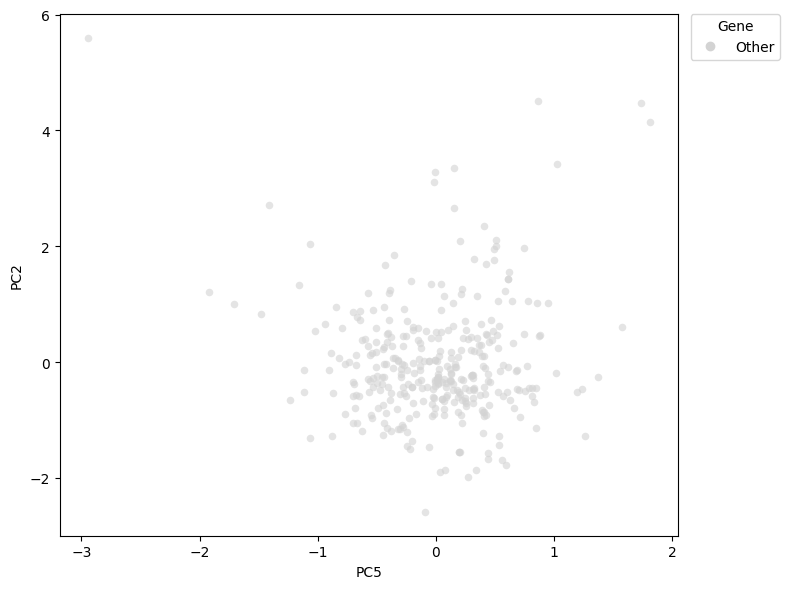

In [ ]:
# Scores = YV
Y_scores = pd.DataFrame(
    pca.transform(Y_scaled),
    index=Y.index,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Example: top 3 and bottom 3 mutants on PC1
for i in range(1,8):
    pc = f"PC{i}"
    top3 = Y_scores[pc].nlargest(3)
    bottom3 = Y_scores[pc].nsmallest(3)
    print(f"Top 3 mutants on PC{i}:\n", top3)
    print(f"Bottom 3 mutants on PC{i}:\n", bottom3)

# Scatter plot PC1 vs PC2
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt

# 1) gènes d'intérêt présents dans X
interesting_genes = [
    "Cre12.g531900","Cre16.g661200","Cre07.g314800","Cre13.g588150",
    "Cre06.g278110","Cre05.g235800","Cre02.g105350","Cre13.g581900",
    "Cre07.g323450","Cre15.g635800"
]
print(X.index)
present_cols = [g for g in interesting_genes if g in X.columns]
print(f"Genes present in data: {present_cols}")

# Function to assign gene labels to mutants
def pick_gene(row):
    """Assign gene label to mutant based on presence"""
    hits = [g for g in present_cols if row[g] > 0]
    return hits[0] if len(hits) >= 1 else "Other"

# Create gene labels for each mutant
label_per_mutant = X[present_cols].apply(pick_gene, axis=1)

# Create color palette
palette_colors = sns.color_palette(n_colors=max(1, len(present_cols)))
palette = {g: c for g, c in zip(present_cols, palette_colors)}
palette["Other"] = "lightgray"

# Prepare data for plotting
df_plot = Y_scores.copy()
df_plot["gene_label"] = label_per_mutant.reindex(df_plot.index)

# Split data for visualization
others = df_plot[df_plot["gene_label"] == "Other"]
interest = df_plot[df_plot["gene_label"] != "Other"]
hue_order_int = [g for g in present_cols if g in interest["gene_label"].unique()]

# Create scatter plot
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=others, x="PC5", y="PC2",
    color="lightgray", s=30, alpha=0.6, linewidth=0, zorder=1, label="Other"
)
sns.scatterplot(        
    data=interest, x="PC5", y="PC2",
    hue="gene_label", hue_order=hue_order_int, palette=palette,
    s=45, alpha=0.95, linewidth=0.4, edgecolor="white", zorder=2, legend=False
)

from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', linestyle='', color='lightgray', label='Other')]
handles += [Line2D([0],[0], marker='o', linestyle='', color=palette[g], label=g) for g in hue_order_int]
ax.legend(handles=handles, title="Gene", bbox_to_anchor=(1.02,1), loc="upper left", borderaxespad=0)

plt.tight_layout(); plt.show()


In [ ]:
# Check gene presence in the dataset
data = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18).csv')
interesting_genes = [
    "Cre12.g531900", "Cre16.g661200", "Cre07.g314800", "Cre13.g588150",
    "Cre06.g278110", "Cre05.g235800", "Cre02.g105350", "Cre13.g581900",
    "Cre07.g323450", "Cre15.g635800"
]
vals = set(data['mutated_genes'].dropna().astype(str).unique())

for el in interesting_genes:
    print(el in vals)

True
True
True
True
False
True
True
True
True
True


(1000, 2)


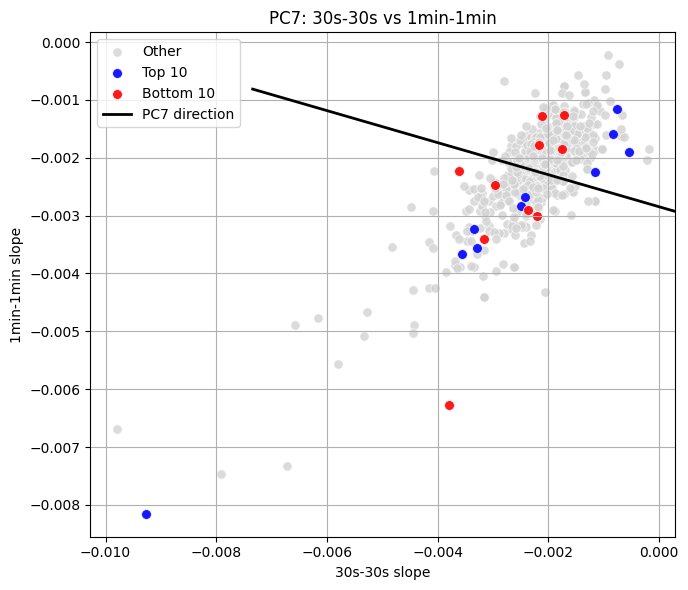

Non-NaN rows: 589 / 589


In [ ]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

def plot_pc_direction(PC_TARGET, x_col, y_col, N_PER_SIDE=10):
    """
    Visualize PC direction in 2D space showing extreme mutants
    
    Parameters:
    -----------
    PC_TARGET : str
        Target PC to visualize (e.g., "PC7")
    x_col, y_col : str
        Light regimes to plot on x and y axes
    N_PER_SIDE : int
        Number of extreme mutants to highlight on each side
    """
    
    # Get extreme mutants on target PC
    pc_num = int(PC_TARGET.replace("PC", ""))
    top_ids = Y_scores[PC_TARGET].nlargest(N_PER_SIDE).index
    bot_ids = Y_scores[PC_TARGET].nsmallest(N_PER_SIDE).index
    
    # Prepare data for plotting
    plot_df = Y[[x_col, y_col]].dropna().copy()
    plot_df['group'] = 'Other'
    plot_df.loc[plot_df.index.isin(top_ids), 'group'] = f'Top {N_PER_SIDE}'
    plot_df.loc[plot_df.index.isin(bot_ids), 'group'] = f'Bottom {N_PER_SIDE}'
    
    # Calculate PC direction in original units
    ix, iy = Y.columns.get_loc(x_col), Y.columns.get_loc(y_col)
    v_std = pca.components_[pc_num - 1][[ix, iy]]
    sx, sy = yscaler.scale_[ix], yscaler.scale_[iy]
    v_orig = np.array([v_std[0] / sx, v_std[1] / sy])
    v_orig = v_orig / np.linalg.norm(v_orig)
    
    # Create plot
    plt.figure(figsize=(7, 6))
    
    # Scatter plots
    sns.scatterplot(
        data=plot_df[plot_df['group'] == 'Other'], x=x_col, y=y_col,
        color='lightgrey', alpha=0.8, s=45, label='Other'
    )
    sns.scatterplot(
        data=plot_df[plot_df['group'] == f'Top {N_PER_SIDE}'], x=x_col, y=y_col,
        color='blue', alpha=0.9, s=50, label=f'Top {N_PER_SIDE}'
    )
    sns.scatterplot(
        data=plot_df[plot_df['group'] == f'Bottom {N_PER_SIDE}'], x=x_col, y=y_col,
        color='red', alpha=0.9, s=50, label=f'Bottom {N_PER_SIDE}'
    )
    
    # Add PC direction line
    center = plot_df[[x_col, y_col]].mean().values
    xmin, xmax = plt.xlim()
    ymin, ymax = plt.ylim()
    max_extent = max(xmax - xmin, ymax - ymin) / 2
    t = np.linspace(-max_extent, max_extent, 1000)
    pc_line = center[None, :] + t[:, None] * v_orig
    
    plt.plot(pc_line[:, 0], pc_line[:, 1], color='black', lw=2, label=f'{PC_TARGET} direction')
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    
    plt.title(f'{PC_TARGET}: {x_col} vs {y_col}')
    plt.xlabel(f'{x_col} slope')
    plt.ylabel(f'{y_col} slope')
    plt.legend(title='', loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Data summary
    non_na_count = Y[[x_col, y_col]].dropna().shape[0]
    total_count = Y.shape[0]
    print(f"Non-NaN rows: {non_na_count} / {total_count}")

# Example: visualize PC7 direction
plot_pc_direction("PC7", "30s-30s", "1min-1min", N_PER_SIDE=10)


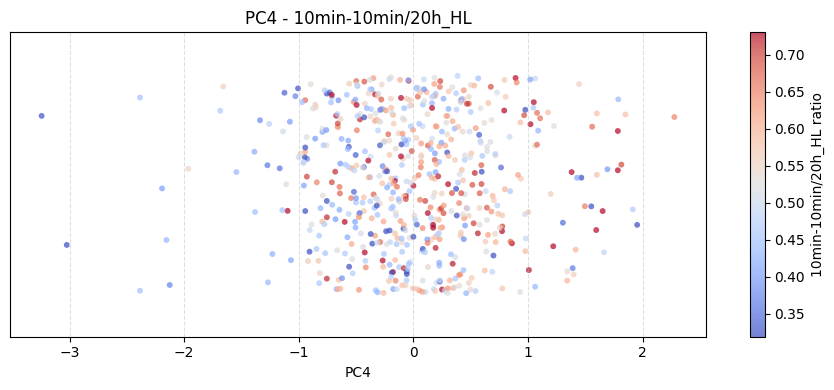

In [ ]:
# =============================================================================
# RATIO ANALYSIS AND GENE ANNOTATION
# =============================================================================

def plot_pc_vs_ratio(PC_TARGET, slope1, slope2, genes_to_show):
    """
    Plot PC scores vs ratio of two light regimes, highlighting genes of interest
    
    Parameters:
    -----------
    PC_TARGET : str
        Target PC to plot on x-axis
    slope1, slope2 : str
        Light regimes to compute ratio (slope1/slope2)
    genes_to_show : list
        List of genes to highlight
    """
    
    # Calculate ratio
    ratio = (Y[slope1] / Y[slope2]).replace([np.inf, -np.inf], np.nan)
    
    # Prepare plotting data
    plot_df = (
        Y_scores[[PC_TARGET]]
        .assign(ratio=ratio)
        .dropna(subset=["ratio"])
    )
    
    # Identify mutants with genes of interest
    present_cols = [g for g in genes_to_show if g in X.columns]
    labels = X[present_cols].apply(
        lambda row: ", ".join([g for g, v in row.items() if v > 0]),
        axis=1
    ) if present_cols else pd.Series("", index=X.index)
    
    labels = labels.reindex(plot_df.index).fillna("")
    has_gene = labels != ""
    
    # Create plot
    vmin, vmax = np.percentile(plot_df["ratio"], [5, 95])
    j = 0.06
    y = np.random.uniform(-j, j, size=len(plot_df))
    
    plt.figure(figsize=(9, 4))
    sc = plt.scatter(
        plot_df[PC_TARGET], y,
        c=plot_df["ratio"], cmap="coolwarm",
        vmin=vmin, vmax=vmax,
        s=18, alpha=0.7, edgecolors="none"
    )
    
    # Highlight genes of interest
    plt.scatter(
        plot_df.loc[has_gene, PC_TARGET],
        y[has_gene.values],
        facecolors="none", edgecolors="black", s=90, linewidths=1.2, 
        label="genes of interest"
    )
    
    # Add gene labels
    for mid, gene_text in labels[has_gene].items():
        plt.text(
            plot_df.at[mid, PC_TARGET],
            y[plot_df.index.get_loc(mid)],
            gene_text, fontsize=8, ha="left", va="center"
        )
    
    plt.xlabel(PC_TARGET)
    plt.yticks([])
    plt.ylim(-j*1.4, j*1.4)
    plt.title(f"{PC_TARGET} - {slope1}/{slope2}")
    cb = plt.colorbar(sc)
    cb.set_label(f"{slope1}/{slope2} ratio")
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

# Example: plot PC4 vs 10min-10min/20h_HL ratio
genes_to_show = [
    "Cre12.g531900", "Cre16.g661200", "Cre07.g314800", "Cre13.g588150",
    "Cre06.g278110", "Cre05.g235800", "Cre02.g105350", "Cre13.g581900",
    "Cre07.g323450", "Cre15.g635800"
]

plot_pc_vs_ratio("PC4", "10min-10min", "20h_HL", genes_to_show)


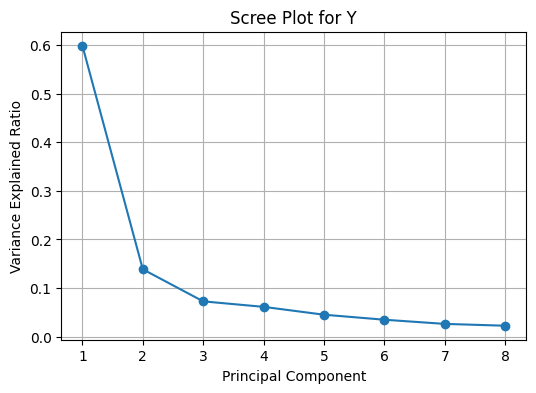

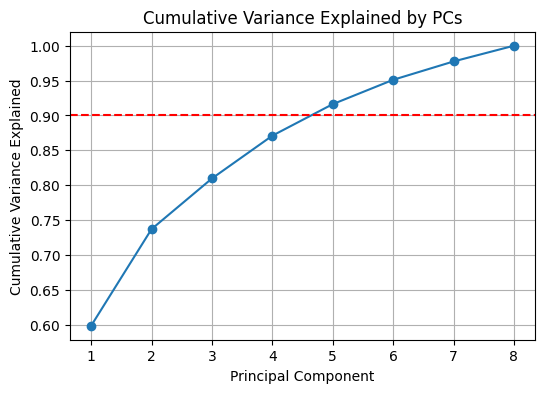

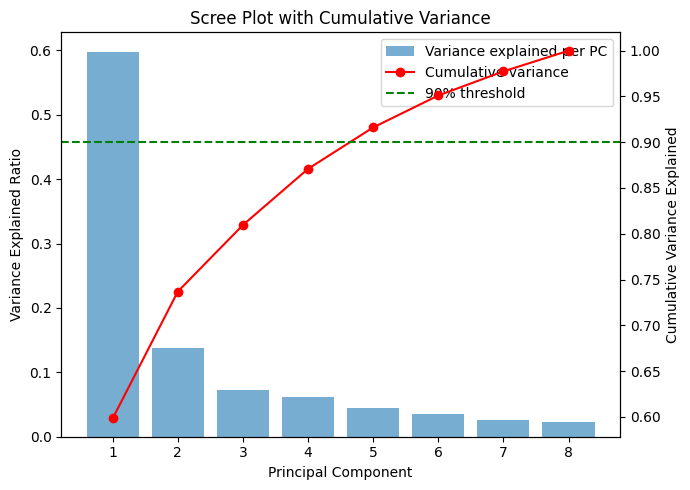

In [ ]:
# =============================================================================
# PCA SCREE PLOTS AND VARIANCE ANALYSIS
# =============================================================================

def plot_scree_analysis(Y_data, title_suffix=""):
    """
    Create comprehensive scree plot analysis
    
    Parameters:
    -----------
    Y_data : array-like
        Data to perform PCA on
    title_suffix : str
        Suffix to add to plot titles
    """
    
    # Fit PCA
    yscaler = StandardScaler()
    Y_scaled = yscaler.fit_transform(Y_data)
    pca = PCA()
    pca.fit(Y_scaled)
    
    var_ratio = pca.explained_variance_ratio_
    cum_var = np.cumsum(var_ratio)
    pcs = np.arange(1, len(var_ratio) + 1)
    
    # Create combined scree plot
    fig, ax1 = plt.subplots(figsize=(7, 5))
    
    # Bar plot for individual variance
    ax1.bar(pcs, var_ratio, alpha=0.6, label='Variance explained per PC')
    ax1.set_xlabel('Principal Component')
    ax1.set_ylabel('Variance Explained Ratio')
    ax1.set_xticks(pcs)
    
    # Line plot for cumulative variance
    ax2 = ax1.twinx()
    ax2.plot(pcs, cum_var, color='red', marker='o', label='Cumulative variance')
    ax2.set_ylabel('Cumulative Variance Explained')
    ax2.axhline(y=0.9, color='green', linestyle='--', label='90% threshold')
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    
    plt.title(f'Scree Plot with Cumulative Variance{title_suffix}')
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"Variance explained by first 3 PCs: {cum_var[2]:.3f}")
    print(f"Number of PCs for 90% variance: {np.argmax(cum_var >= 0.9) + 1}")

# Run scree plot analysis
plot_scree_analysis(Y, " (Light Regimes)")



### VARIMAX ROTATION ANALYSIS


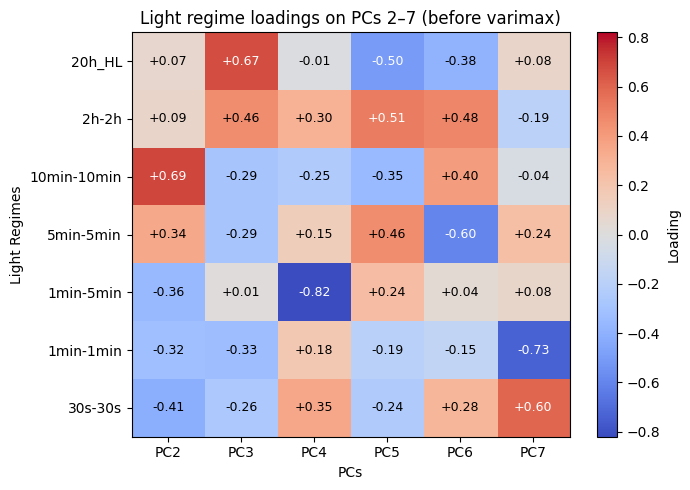

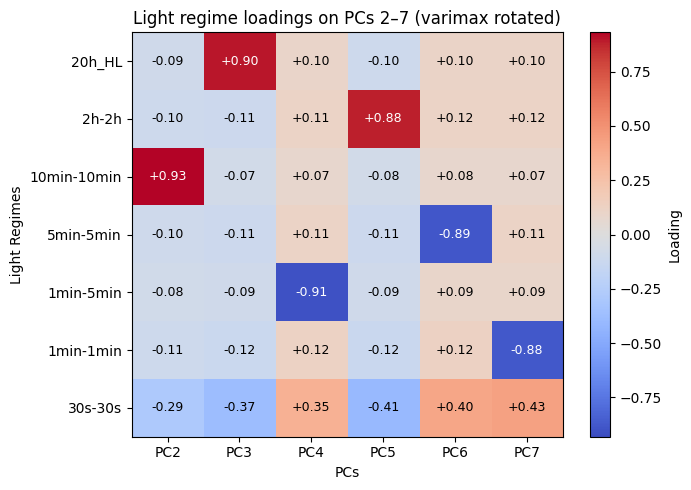

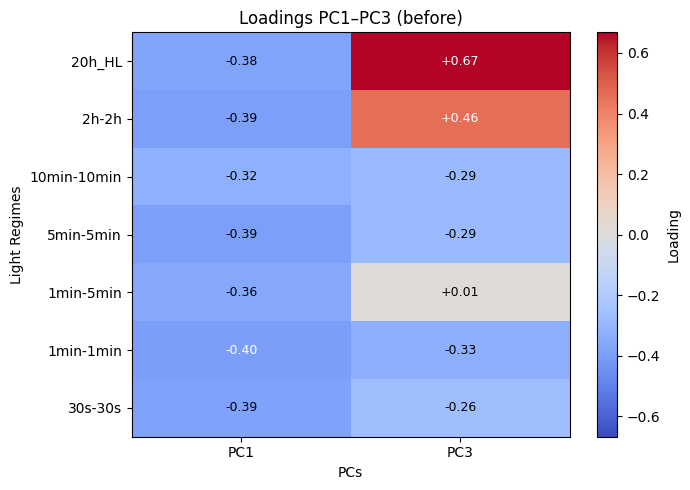

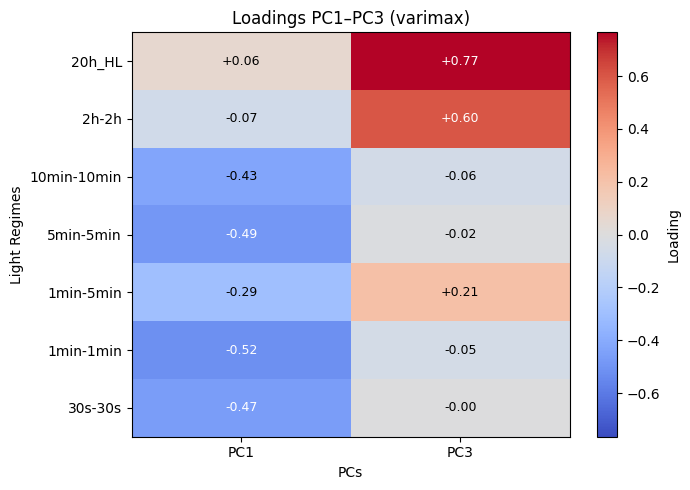

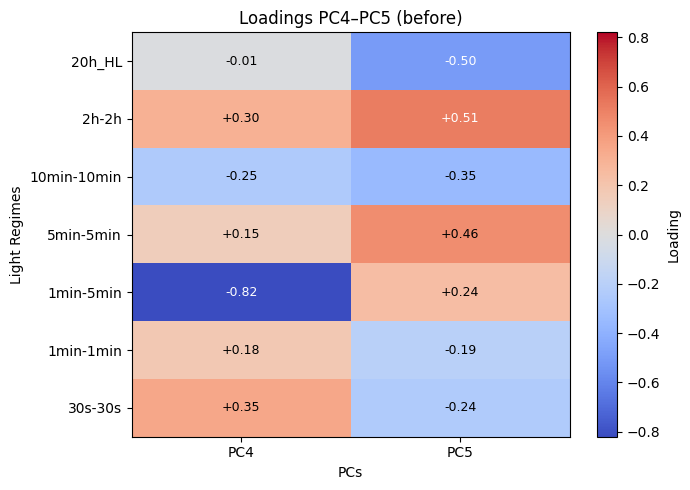

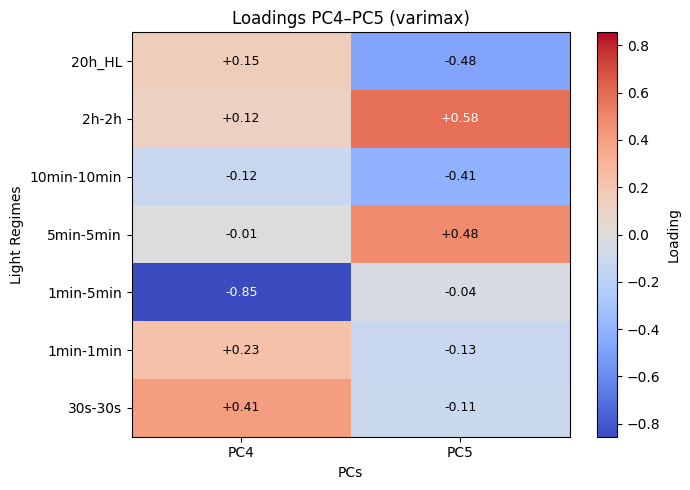

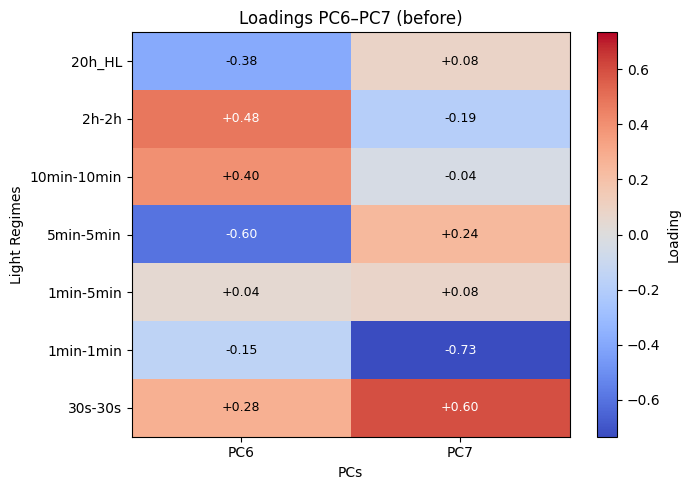

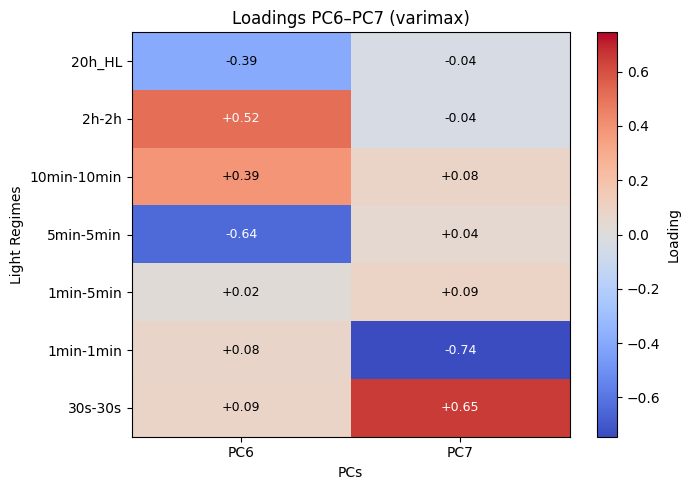

(array([[-0.38484401,  0.08416411],
        [ 0.48106867, -0.19138741],
        [ 0.39617582, -0.03806585],
        [-0.60002729,  0.2365362 ],
        [ 0.04412216,  0.07808875],
        [-0.15144882, -0.73374461],
        [ 0.28035065,  0.59532333]]),
 array([[-0.39218532, -0.03713735],
        [ 0.51651221, -0.03565582],
        [ 0.38892763,  0.08449605],
        [-0.64357164,  0.04239892],
        [ 0.01822207,  0.08782126],
        [ 0.07939574, -0.74499277],
        [ 0.08556238,  0.65244573]]),
 array([[ 0.07828445,  0.80537115],
        [-1.20244131,  0.09263007],
        [-0.31719272, -0.09290862],
        ...,
        [-0.33312636, -0.2137788 ],
        [-0.74588378, -0.24126554],
        [ 0.96997925, -0.15757877]]),
 array([[-0.17090999,  0.79091144],
        [-1.17346117, -0.27827024],
        [-0.2737828 , -0.18516536],
        ...,
        [-0.25211821, -0.30514088],
        [-0.63685866, -0.4571244 ],
        [ 0.97185556,  0.14555957]]))

In [ ]:
# --- Varimax (orthogonal) ---
def varimax(Phi, gamma=1.0, q=100, tol=1e-6):
    p, k = Phi.shape
    R = np.eye(k)
    d_old = 0
    for _ in range(q):
        Lambda = Phi @ R
        # Kaiser normalization inside objective
        M = Phi.T @ (Lambda**3 - (gamma/p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda)))
        U, S, Vt = np.linalg.svd(M, full_matrices=False)
        R = U @ Vt
        d = S.sum()
        if d_old and (d - d_old) < tol:
            break
        d_old = d
    return Phi @ R, R

# --- Heatmap helper (no custom colors; labels like your figure) ---
def plot_loadings_heatmap(loadings, regime_names, pc_names, title):
    L = np.asarray(loadings, dtype=float)
    vmax = np.nanmax(np.abs(L)) or 1.0  # échelle symétrique
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(L, aspect='auto', cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(len(regime_names)))
    ax.set_yticklabels(regime_names)
    ax.set_xticks(range(len(pc_names)))
    ax.set_xticklabels(pc_names)
    ax.set_xlabel('PCs')
    ax.set_ylabel('Light Regimes')
    ax.set_title(title)
    for i in range(L.shape[0]):
        for j in range(L.shape[1]):
            val = L[i, j]
            txt_color = 'white' if abs(val) > 0.6 * vmax else 'black'
            ax.text(j, i, f"{val:+.2f}", ha='center', va='center', fontsize=9, color=txt_color)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Loading')
    plt.tight_layout()
    plt.show()

Y_std = pd.DataFrame(
    StandardScaler(with_mean=True, with_std=True).fit_transform(Y.values),
    index=Y.index, columns=Y.columns
)

pca = PCA(n_components=7, svd_solver='full', random_state=0)
scores = pca.fit_transform(Y_std.values)          # (n_mutants × 7)
loadings_all = pca.components_.T                  # (n_regimes × 7), colonnes = PC1..PC7
regimes = list(Y.columns)
regime_order = ['20h_HL','2h-2h','10min-10min','5min-5min','1min-5min','1min-1min','30s-30s']
loadings_all = pca.components_.T                  # (n_regimes × 7)
regimes_orig = list(Y.columns)

regimes = [r for r in regime_order if r in regimes_orig]
order_idx = [regimes_orig.index(r) for r in regimes]

# Reorder BOTH the matrix and the labels
loadings_all = loadings_all[order_idx, :]

idx = np.arange(1, 7)
L_2_7 = loadings_all[:, idx]
S_2_7 = scores[:, idx]

# Varimax
L_2_7_rot, R_2_7 = varimax(L_2_7.copy())
S_2_7_rot = S_2_7 @ R_2_7

pc_names_2_7 = [f"PC{i}" for i in range(2, 8)]

plot_loadings_heatmap(
    loadings=L_2_7,
    regime_names=regimes,
    pc_names=pc_names_2_7,
    title="Light regime loadings on PCs 2–7 (before varimax)"
)
plot_loadings_heatmap(
    loadings=L_2_7_rot,
    regime_names=regimes,
    pc_names=pc_names_2_7,
    title="Light regime loadings on PCs 2–7 (varimax rotated)"
)

def rotate_pair(j, k):
    ii = np.array([j-1, k-1])
    L = loadings_all[:, ii]
    S = scores[:, ii]                  # (n_mutants × 2)
    L_rot, R = varimax(L.copy())       # rotate within the 2D subspace
    S_rot = S @ R
    plot_loadings_heatmap(L, regimes, [f"PC{j}", f"PC{k}"], f"Loadings PC{j}–PC{k} (before)")
    plot_loadings_heatmap(L_rot, regimes, [f"PC{j}", f"PC{k}"], f"Loadings PC{j}–PC{k} (varimax)")
    return L, L_rot, S, S_rot

rotate_pair(1, 3); rotate_pair(4, 5); rotate_pair(6, 7)


In [13]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LassoCV
import numpy as np
import pandas as pd

def cv_r2_per_pc(X_scaled, PC_scores, pc_names, cv_outer=5, random_state=0):
    """Return DataFrame of CV R^2 per PC."""
    kf = KFold(n_splits=cv_outer, shuffle=True, random_state=random_state)
    rows = []
    for j, name in enumerate(pc_names):
        y = PC_scores[:, j]
        model = LassoCV(cv=5, n_alphas=100, max_iter=5000, random_state=random_state)  # inner CV for alpha
        r2 = cross_val_score(model, X_scaled, y, cv=kf, scoring='r2')
        rows.append({"PC": name, "mean_r2": r2.mean(), "std_r2": r2.std()})
    return pd.DataFrame(rows).set_index("PC").sort_index()

# --- Unrotated PCs (example) ---
# scores: (n_mutants × d) from PCA on standardized Y
pc_names_raw = [f"PC{i+1}" for i in range(scores.shape[1])]
r2_raw = cv_r2_per_pc(X_scaled, scores, pc_names_raw)

# --- Rotated block PCs: 2–7 (your varimax result) ---
S_full_rot = np.column_stack([scores[:, [0]], S_2_7_rot])  # PC1 unchanged + rotated 2–7
pc_names_rot = ["PC1"] + [f"PC{i}" for i in range(2, 2 + S_2_7_rot.shape[1])]
r2_rot = cv_r2_per_pc(X_scaled, S_full_rot, pc_names_rot)

# --- Pairwise rotations (2–3), (4–5), (6–7) ---
def rotate_pair_scores(j, k, loadings_all, scores):
    idx = np.array([j-1, k-1])
    L = loadings_all[:, idx]
    S = scores[:, idx]
    L_rot, R = varimax(L.copy())
    return S @ R  # rotated scores (n × 2)

pairs = [(2,3), (4,5), (6,7)]
cv_tables = []
for (a,b) in pairs:
    S_pair_rot = rotate_pair_scores(a, b, loadings_all, scores)
    names = [f"PC{a}_rot", f"PC{b}_rot"]
    cv_tables.append(cv_r2_per_pc(X_scaled, S_pair_rot, names))

# --- Summary tables ---
print("Unrotated PCs (CV R^2):")
print(r2_raw.round(3))
print("\nRotated PCs 1+(2–7 varimax) (CV R^2):")
print(r2_rot.round(3))
print("\nPairwise rotations (CV R^2):")
for t, (a,b) in zip(cv_tables, pairs):
    print(f"\n(PC{a}–PC{b}) varimax:")
    print(t.round(3))


/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/li

Unrotated PCs (CV R^2):
     mean_r2  std_r2
PC                  
PC1   -0.001   0.001
PC2   -0.018   0.013
PC3   -0.017   0.014
PC4   -0.008   0.004
PC5   -0.008   0.009
PC6   -0.023   0.024
PC7   -0.011   0.010

Rotated PCs 1+(2–7 varimax) (CV R^2):
     mean_r2  std_r2
PC                  
PC1   -0.001   0.001
PC2   -0.017   0.017
PC3   -0.022   0.019
PC4   -0.024   0.026
PC5   -0.006   0.010
PC6   -0.007   0.006
PC7   -0.004   0.005

Pairwise rotations (CV R^2):

(PC2–PC3) varimax:
         mean_r2  std_r2
PC                      
PC2_rot   -0.016   0.013
PC3_rot   -0.020   0.015

(PC4–PC5) varimax:
         mean_r2  std_r2
PC                      
PC4_rot   -0.011   0.005
PC5_rot   -0.007   0.006

(PC6–PC7) varimax:
         mean_r2  std_r2
PC                      
PC6_rot   -0.016   0.009
PC7_rot   -0.016   0.022


### Creating contrasts (imposing artificial eigenvectors that are related to specific light regimes)

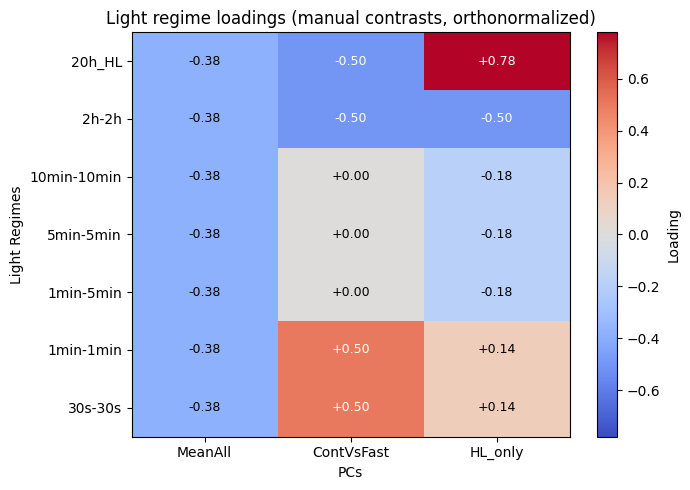


=== MeanAll: top + (sensibles au motif) ===
mutated_genes
Cre04.g229163    13.909
Cre13.g565150    12.541
Cre12.g531900    12.234
Cre05.g248250    11.711
Cre16.g688350     9.020
Name: MeanAll, dtype: float64

=== MeanAll: top - (anti-motif) ===
mutated_genes
Cre12.g489250   -3.781
Cre12.g489300   -3.781
Cre13.g589300   -4.317
Cre06.g251050   -4.736
Cre16.g685451   -7.749
Name: MeanAll, dtype: float64

=== ContVsFast: top + (sensibles au motif) ===
mutated_genes
Cre05.g236000    2.905
Cre14.g613652    2.743
Cre06.g278195    2.405
Cre01.g036100    1.968
Cre11.g467566    1.819
Name: ContVsFast, dtype: float64

=== ContVsFast: top - (anti-motif) ===
mutated_genes
Cre13.g565150   -2.421
Cre17.g724450   -3.189
Cre10.g436200   -3.239
Cre10.g436150   -3.239
Cre12.g531900   -4.187
Name: ContVsFast, dtype: float64

=== HL_only: top + (sensibles au motif) ===
mutated_genes
Cre04.g227500    1.694
Cre01.g030750    1.623
Cre09.g403293    1.623
Cre12.g486900    1.305
Cre10.g436200    1.301
Name: HL_

In [ ]:
def plot_loadings_heatmap(loadings, regime_names, pc_names, title):
    L = np.asarray(loadings, dtype=float)
    vmax = np.nanmax(np.abs(L)) or 1.0
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(L, aspect='auto', cmap='coolwarm',
                   vmin=-vmax, vmax=vmax, interpolation='none')
    ax.set_yticks(range(len(regime_names))); ax.set_yticklabels(regime_names)
    ax.set_xticks(range(len(pc_names)));     ax.set_xticklabels(pc_names)
    ax.set_xlabel('PCs'); ax.set_ylabel('Light Regimes'); ax.set_title(title)
    for i in range(L.shape[0]):
        for j in range(L.shape[1]):
            val = L[i, j]
            ax.text(j, i, f"{val:+.2f}", ha='center', va='center',
                    fontsize=9, color=('white' if abs(val) > 0.6*vmax else 'black'))
    cbar = plt.colorbar(im, ax=ax); cbar.set_label('Loading')
    plt.tight_layout(); plt.show()

regime_order = ['20h_HL','2h-2h','10min-10min','5min-5min','1min-5min','1min-1min','30s-30s']
Y = Y.loc[:, [r for r in regime_order if r in Y.columns]].copy()
regimes = list(Y.columns)
p = len(regimes)

Y_std = pd.DataFrame(
    StandardScaler(with_mean=True, with_std=True).fit_transform(Y.values),
    index=Y.index, columns=regimes
)

contrasts = {
    "MeanAll": {r: 1 for r in regimes},                                  # tous +1
    "ContVsFast": {'20h_HL':+1, '2h-2h':+1, '1min-1min':-1, '30s-30s':-1},# le reste 0
    "HL_only": {'20h_HL': 1}                                             # le reste 0
}

V_cols, names = [], []
for name, wmap in contrasts.items():
    v = np.array([wmap.get(r, 0.0) for r in regimes], dtype=float)
    if np.allclose(v, 0):
        continue
    v = v / np.linalg.norm(v)
    V_cols.append(v); names.append(name)

V_stack = np.column_stack(V_cols)  # (p × k)

Q, R = np.linalg.qr(V_stack)       # orthog
V = Q                               # (p × k)
pc_names = names           

S = Y_std.values @ V                # (n_mutants × k)
scores_df = pd.DataFrame(S, index=Y_std.index, columns=pc_names)

Sigma = np.cov(Y_std.values, rowvar=False)        
var_along = pd.Series(np.diag(V.T @ Sigma @ V), index=pc_names)

plot_loadings_heatmap(V, regimes, pc_names, "Light regime loadings (manual contrasts, orthonormalized)")

def top_mutants(scores_df, comp, n=5):
    s = scores_df[comp].sort_values(ascending=False)
    return s.head(n), s.tail(n)

for comp in pc_names:
    top_pos, top_neg = top_mutants(scores_df, comp, n=5)
    print(f"\n=== {comp}: top + (sensibles au motif) ===")
    print(top_pos.round(3))
    print(f"\n=== {comp}: top - (anti-motif) ===")
    print(top_neg.round(3))

total_var = p 
prop_var_along = var_along / total_var

print("\nVariance along each contrast (on standardized Y):")
print(var_along.round(3))

print("\nProportion of total variance explained by each contrast:")
print(prop_var_along.round(3))
